# 🧠 Alzheimer's Detection from EEG Signals
**Goal:** Binary classification (AD vs Healthy) using a PyTorch Neural Network on Power Spectral Density (PSD) features.

## 1. Setup & Imports

In [1]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## 2. Load Participant Data & Filter Labels

In [2]:
data_path = 'C:/Users/georg/NeuoData'

In [3]:
tsv_path = os.path.join(data_path, 'participants.tsv')
participants = pd.read_csv(tsv_path, sep='\t')

print("Columns:", participants.columns.tolist())
print("\nFirst 3 rows:")
print(participants.head(3))

Columns: ['participant_id', 'Gender', 'Age', 'Group', 'MMSE']

First 3 rows:
  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14


In [4]:
group_map = {}
for idx, row in participants.iterrows():
    sub = row['participant_id']
    if not sub.startswith('sub-'):
        sub = f"sub-{sub}"
    code = row['Group'].strip()
    
    if code == 'A':
        group_map[sub] = 'AD'
    elif code == 'C':
        group_map[sub] = 'Healthy'
    elif code == 'F':
        group_map[sub] = 'FTD'
    else:
        print(f"⚠️ Unknown code: {code} for {sub}")

# Count per group
for g in ['AD', 'Healthy', 'FTD']:
    count = sum(1 for v in group_map.values() if v == g)
    print(f"   {g}: {count}")

   AD: 36
   Healthy: 29
   FTD: 23


## 3. Load EEG Files & Extract PSD Features

In [5]:
eeg_data = {}

for sub, group in group_map.items():
    eeg_folder = os.path.join(data_path, sub, 'eeg')
    if not os.path.exists(eeg_folder):
        print(f"⚠️ Missing folder: {sub}")
        continue
    
    set_files = [f for f in os.listdir(eeg_folder) if f.endswith('.set')]
    if not set_files:
        print(f"⚠️ No .set file: {sub}")
        continue
    
    set_file = os.path.join(eeg_folder, set_files[0])
    
    try:
        raw = mne.io.read_raw_eeglab(set_file, preload=True, verbose=False)
        raw.set_eeg_reference('average', verbose=False)
        raw.notch_filter(60, verbose=False)
        raw.filter(1, 40, method='fir', verbose=False)
        
        key = f"{group}_{sub[-3:]}"
        eeg_data[key] = raw
    except Exception as e:
        print(f"❌ Error loading {sub}: {e}")

print(f"\n✅ Successfully loaded {len(eeg_data)} subjects")


✅ Successfully loaded 88 subjects


In [6]:
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 40)
}

def extract_psd_features(raw, bands):
    data, _ = raw[:, :]
    sfreq = raw.info['sfreq']
    n_channels = data.shape[0]
    features = []
    
    for ch in range(n_channels):
        freqs, psd = welch(data[ch, :], sfreq, nperseg=sfreq*2)
        for band_name, (low, high) in bands.items():
            idx = (freqs >= low) & (freqs <= high)
            band_power = np.trapezoid(psd[idx], freqs[idx])
            features.append(band_power)
    
    return np.array(features)

In [7]:
filtered_keys = [k for k in eeg_data.keys() if k.startswith('AD') or k.startswith('Healthy')]

X = []
y = []
label_map = {'AD': 0, 'Healthy': 1}

for key in filtered_keys:
    raw = eeg_data[key]
    group = key.split('_')[0]
    features = extract_psd_features(raw, bands)
    X.append(features)
    y.append(label_map[group])

X = np.array(X)
y = np.array(y)

## 4. Train / Validation / Test Split

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 45, Val: 10, Test: 10


## 5. Standardize Features

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 6. Create PyTorch DataLoaders

In [10]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

## 7. Define the Neural Network

In [11]:
class EEGClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(16, 2)  # 2 classes: AD, Healthy
        )
    def forward(self, x):
        return self.net(x)

In [12]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(weights, dtype=torch.float32)

model = EEGClassifier(input_dim=X.shape[1])
criterion = nn.CrossEntropyLoss(weight=class_weights)   # <-- ADD THIS
optimizer = optim.Adam(model.parameters(), lr=0.0005)

## 8. Training Loop with Early Stopping

In [13]:
EPOCHS = 150
PATIENCE = 30
LEARNING_RATE = 0.0005

model = EEGClassifier(input_dim=X.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop
best_val_acc = 0.0
patience_counter = 0
train_losses, val_accuracies = [], []

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    
    avg_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    # Validation Phase
    model.eval()
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds = torch.argmax(model(X_batch), dim=1)
            correct += (preds == y_batch).sum().item()
    val_acc = correct / len(val_loader.dataset)
    val_accuracies.append(val_acc)

    # Early Stopping Check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict()  # Save the best weights
    else:
        patience_counter += 1

    # Progress Logging
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"⏹️ Early stopping at epoch {epoch+1}")
        break

# Load the best version of the model
model.load_state_dict(best_model_state)
print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

Epoch  20 | Loss: 0.5945 | Val Acc: 0.6000
⏹️ Early stopping at epoch 35

✅ Best Validation Accuracy: 0.7000


## 9. Final Evaluation on Test Set

✅ PyTorch Test Accuracy: 0.9000 (90.00%)

Confusion Matrix:
[[6 0]
 [1 3]]

Classification Report:
              precision    recall  f1-score   support

          AD       0.86      1.00      0.92         6
     Healthy       1.00      0.75      0.86         4

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



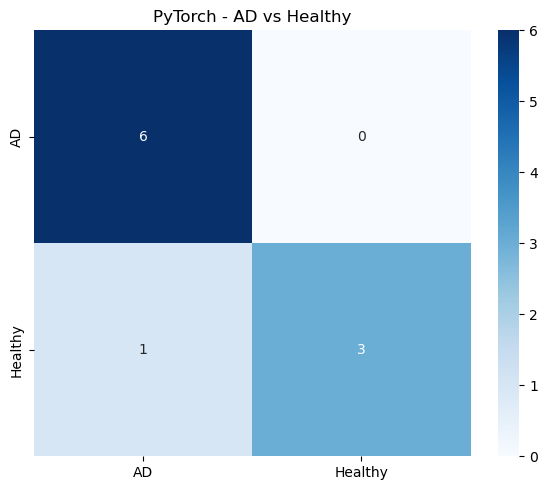

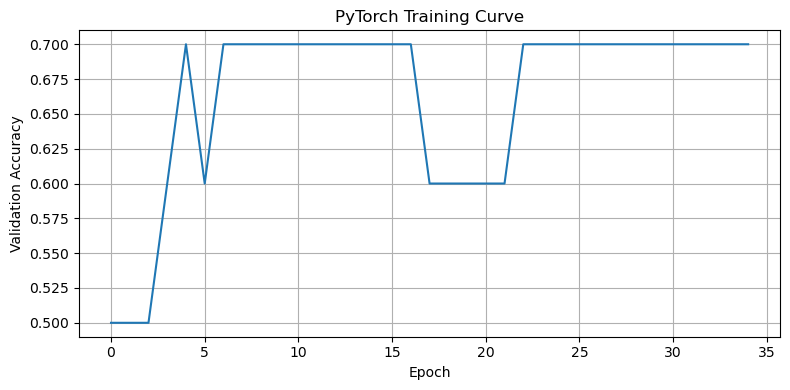

In [14]:
model.eval()
preds, truths = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        preds.extend(torch.argmax(model(inputs), dim=1).cpu().numpy())
        truths.extend(labels.cpu().numpy())

test_acc = accuracy_score(truths, preds)
print(f"✅ PyTorch Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(truths, preds)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(truths, preds, target_names=['AD', 'Healthy']))

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['AD', 'Healthy'],
            yticklabels=['AD', 'Healthy'])
plt.title('PyTorch - AD vs Healthy')
plt.tight_layout()
plt.savefig('pytorch_confusion_matrix.png')
plt.show()

# Plot training curve - FIXED: now matches 'val_accuracies'
plt.figure(figsize=(8,4))
plt.plot(val_accuracies)   # <--- CHANGED from val_accs to val_accuracies
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('PyTorch Training Curve')
plt.grid(True)
plt.tight_layout()
plt.savefig('pytorch_training_curve.png')
plt.show()

## 10. Baseline Comparison

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=1000)
scores = cross_val_score(lr, X, y, cv=5, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression CV Accuracy: 0.5538 (+/- 0.0308)
